# Regresyon Temelleri

Regresyon analizi, verilerdeki eğilimleri bulmanın bir yoludur. Örneğin, ne kadar yediğiniz ile ne kadar kilonuz olduğu arasında bir bağlantı olduğunu tahmin edebilirsiniz; regresyon analizi bunu ölçmenize yardımcı olur.

Regresyon analizi, verileriniz hakkında tahminlerde bulunabilmeniz için size bir grafik denklemi sağlayacaktır. Örneğin, son birkaç yıldır kilo alıyorsanız, aynı oranda kilo almaya devam ederseniz on yıl içinde ne kadar kilo alacağınızı tahmin edebilir. Ayrıca, modelinizin ne kadar doğru olduğunu söylemek için size bir dizi istatistik (bir p değeri ve bir korelasyon katsayısı dahil) verecektir.

Bu dersin sonunda şunları yapabiliyor olmayı hedefliyoruz:

1. Makine Öğrenmesine giriş derslerinde öğretilen lineer regresyonu uygulamak
2. Lineer regresyon modelinden elde edilen katsayıları yorumlamak
3. `scikit-learn` ve `statsmodels` yöntemlerini kullanarak lineer regresyon modelleri eğitmek
4. Oluşturduğunuz modeli kullanarak örneklem kümesinde dışında verilere ilişkin tahminler gerçekleştirmek

In [1]:
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid", {"font.family": ["serif"]})
sns.set_context("talk")

In [2]:
anscombe = pd.read_csv('data/anscombe.csv')
anscombe.head(15)

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33
5,I,14.0,9.96
6,I,6.0,7.24
7,I,4.0,4.26
8,I,12.0,10.84
9,I,7.0,4.82


Anscombe verileri, regresyon mantığını daha iyi anlayabilmemiz için dört adet veri kümesini içerir. Ama ilk olarak `dataset=I` e odaklanacağız.

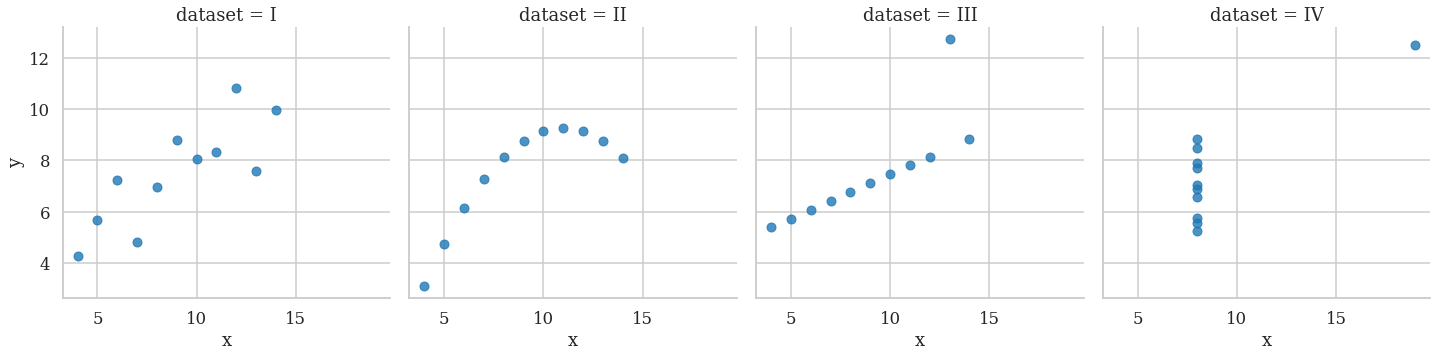

In [3]:
sns.lmplot(x="x", y="y", col="dataset", fit_reg=False, data=anscombe);

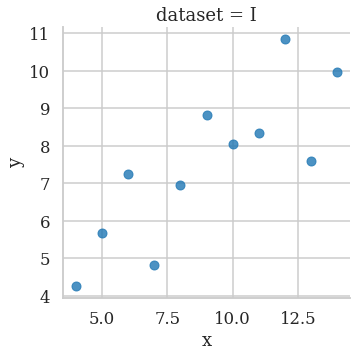

In [4]:
sns.lmplot(x="x", y="y", fit_reg=False, col="dataset", data=anscombe.query("dataset=='I'"));

Lineer bir regresyon modeli oluşturmak için kullanılabilecek `x` ve `y` değişkenleri arasında bir korelasyon görmekteyiz. Grafikteki noktalar incelendiğinde `dataset=I` de x değişkenindeki değerler arttıkça, y değişkenindeki değerlerin de sabit bir miktarda artma eğiliminde olduğunu gösteriyor. En basit anlamıyla, doğrusal bir model:

- **Özellik (Feature)** ile **Hedef (Target)** 
- **Bağımsız Değişken (Independent Variable)** ile **Bağımlı Değişken (Dependent Variable)**

arasındaki düz bir çizgi ilişkisidir. Makine öğrenmesinde çok önemli bir istatiksel ölçü olan **korelasyon** kavramını ise önümüzdeki derslerde detaylı bir şekilde konuşuyor olacağız.

Görselleştirmeleri konuşurken öğrendiğimiz yöntemleri kullanarak, hızlıca bir **Lineer Regresyon** çizgisi oluşturabiliriz.

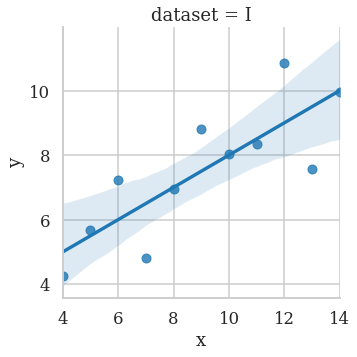

In [5]:
sns.lmplot(x="x", y="y", col="dataset", data=anscombe.query("dataset=='I'"));

- Lineer Regresyon doğrusunun (6,6), (7,8) ve (10,8) gibi noktalarda kesiştiğini ve bize 1/2'lik bir eğim verdiğini görüyoruz: Yani `x` değişkenindeki her 1 birimlik değişim `y` değişkenindeki 0.5 birimlik bir değişime denk geliyor. Dolayısıyla, bu doğrunun denklemini `𝑦=0.5𝑥+3` olarak yazabiliriz. İşte bu denklem bizim oluşturduğumuz regresyon doğrusunun matematiksel arka planı...

- Ancak grafikten görülebildiği gibi oluşturduğumuz regresyon doğrusu veri seti içerisinde yer alan tüm noktalarımızla kesişmemiş, aslında böyle regresyon doğrusu oluşturmamız da zaten imkansız. Bunun için daha farklı regresyon çeşitleri görmemiz lazım.

> **NOT:** Aslında diğer regresyon çeşitlerinin de tüm noktaları kesmesini istemeyiz. Ama bu konu şimdilik sonraya kalabilir :)

- Regresyon problemlerinde oluşturduğumuz çizginin bir veri kümesine ne kadar iyi uyduğu (veri noktaların çizgiye yakınlığı) bize modelimizin başarısı hakkında bilgi verir. Veri setinde yer alan her bir noktadan çizgiye olan mesafeye **hata miktarı** denir. Bunlar gözlemlenen `𝑦` ile tahmin edilen `𝑦ˆ` arasındaki farktır.

![](https://upload.wikimedia.org/wikipedia/commons/e/ed/Residuals_for_Linear_Regression_Fit.png)

- **Ordinary Least Squares (OLS)**, karesel hataların toplamını en aza indirmeyi amaçlayan bir model/çizgi uydurma yaklaşımıdır. Bu, OLS'nin her hatayı aldığı, karesini aldığı ve ardından bu uzunluğu en aza indirmeye çalıştığı anlamına gelir. Sonuçlardan biri, şekildeki alt ve üst noktaların modelimizin hatasına büyük ölçüde katkıda bulunması ve güçlü bir etkiye sahip olmasıdır. 
- Bu yaklaşımda aykırı değerler özellikle **tehlikelidir**, doğru sonuçlar elde etmemizi ciddi anlamda baltalarlar!

## Scikit-Learn Kullanarak Modelleme

Hadi ilk modelimizi eğitmeye başlayalım...

In [6]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression  

X1 = anscombe.query("dataset=='I'").loc[:,'x'].values.reshape(-1,1)
y1 = anscombe.query("dataset=='I'").loc[:,'y']

linreg_model = LinearRegression()
linreg_model.fit(X1, y1)

LinearRegression()

İşte **Scikit-Learn** kullanarak bir model oluşturmak bu kadar kolay :)

- Ama şimdi oluşturduğumuz `linreg_model` modelin biraz daha detayına inelim.

In [7]:
linreg_model.coef_ # Oluşturduğumuz modele ilişkin hesaplanan katsayı değeri

# Yukarıdaki grafiği inceleyerek de bu değerin 1/2 olması gerektiğini konuşmuştuk :)

array([0.50009091])

- Ve sabit değer...

In [8]:
# Bu da 3 olmalıydı diye hatırlıyorum
linreg_model.intercept_

3.0000909090909103

- Artık oluşturduğumuz modeli kullanarak tahminlerimizi gerçekleştirebiliriz. Hadi **x=0** deneyelim;

In [9]:
linreg_model.predict([[0]])
# Aaa!!! Modelimizdeki sabit değeri elde ettik :)

array([3.00009091])

- Bir de **x=15**;

In [10]:
linreg_model.predict([[15]])

array([10.50145455])

Lineer Regresyonda, model bir dizi parametreyi öğrenir, ve buradaki her bir $\beta_1$, $\beta_2$, $\beta_3$,... değeri modelimize dahil ettiğimiz featurelara ait katsayı değerlerini içerir. Yani genel denklemimiz şu şekilde oluşuyor:

$$\hat{y} = \beta_0 + \beta_1x_1 + \beta_2x_2 + \beta_3x_3 + \beta_4x_4 ...\ .$$

Ve tabiki, $x_1$, $x_2$, $x_3$,... değerleri de veri setimizdeki featurelara ait değerleri temsil eder. Dolayısıyla, $\beta_0$ da denklemimizdeki sabit değerimize karşılık geliyor.

## Statsmodels Kullanarak Modelleme

Az önce bir lineer regresyon modelini, `sklearn` kütüphanesini kullanarak nasıl eğitebileceğimizi gördük. Şimdi ise farklı bir araca, `statsmodels` bakalım. Bu 2 yaklaşımın temel farkını da şu şekilde açıklayabiliriz:

- `sklearn` daha çok makine öğrenimi için tasarlanmıştır.
- `statsmodels` daha çok istatistikçiler için tasarlanmıştır.

In [11]:
# Elimizde 3 farklı csv dosyasında tutulan veriler var
housing_price_index = pd.read_csv('data/monthly-hpi.csv')

shiller = pd.read_csv('data/shiller.csv')

gross_domestic_product = pd.read_csv('data/gdp.csv')

In [12]:
print(housing_price_index.head())
print(shiller.head())
print(gross_domestic_product.head())

         date  housing_price_index
0  2010-11-01               186.07
1  2010-12-01               183.27
2  2011-01-01               181.35
3  2011-02-01               179.66
4  2011-03-01               178.84
         date    sp500  consumer_price_index  long_interest_rate
0  2010-11-01  1198.89                218.80                2.76
1  2010-12-01  1241.53                219.18                3.29
2  2011-01-01  1282.62                220.22                3.39
3  2011-02-01  1321.12                221.31                3.58
4  2011-03-01  1304.49                223.47                3.41
         date  total_expenditures  labor_force_pr  producer_price_index  \
0  2011-01-01              5766.7            64.2                 192.7   
1  2011-04-01              5870.8            64.2                 203.1   
2  2011-07-01              5802.6            64.0                 204.6   
3  2011-10-01              5812.9            64.1                 201.1   
4  2012-01-01            

- Yukarıda elde ettiğimiz çıktıda da gördüğümüz gibi elimizdeki 3 csv dosyasında da **date** sütunları ortak. İlk projede yaptığımıza benzer bir şekilde, bu birleştirme işlemini `pandas` kütüphanesinden yararlanarak yapabiliriz.

In [13]:
housing_df = shiller.merge(gross_domestic_product, on='date').merge(housing_price_index, on='date')

In [14]:
housing_df.head()

,date,sp500,consumer_price_index,long_interest_rate,total_expenditures,labor_force_pr,producer_price_index,gross_domestic_product,housing_price_index
0,2011-01-01,1282.62,220.22,3.39,5766.7,64.2,192.7,14881.3,181.35
1,2011-04-01,1331.51,224.91,3.46,5870.8,64.2,203.1,14989.6,180.80
2,2011-07-01,1325.19,225.92,3.00,5802.6,64.0,204.6,15021.1,184.25
3,2011-10-01,1207.22,226.42,2.15,5812.9,64.1,201.1,15190.3,181.51
4,2012-01-01,1300.58,226.66,1.97,5765.7,63.7,200.7,15291.0,179.13


- Artık modelleme aşamasına geçebiliriz.

In [15]:
import statsmodels.api as sm

# Veri seti içerisindeki feature ve target sütunlarını oluşturma
X = housing_df.drop(columns=["housing_price_index", "date"])
y = housing_df.loc[:,"housing_price_index"]

In [16]:
# Housing_Price_Index sütununu tahmin etmek için modelimizi oluşturuyoruz
housing_model = sm.OLS(y, X, data=housing_df)

results = housing_model.fit()

# Oluşturduğumuz modelin özeti
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     housing_price_index   R-squared (uncentered):                   1.000
Model:                             OLS   Adj. R-squared (uncentered):              1.000
Method:                  Least Squares   F-statistic:                          1.863e+04
Date:                 Fri, 24 Jun 2022   Prob (F-statistic):                    4.54e-30
Time:                         16:54:48   Log-Likelihood:                         -51.586
No. Observations:                   23   AIC:                                      117.2
Df Residuals:                       16   BIC:                                      125.1
Df Model:                            7                                                  
Covariance Type:             nonrobust                                                  
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
sp500                      0.0266      0.010      2.717      0.015       0.006       0.047
consumer_price_index       2.4016      0.652      3.682      0.002       1.019       3.784
long_interest_rate         1.1669      1.734      0.673      0.511      -2.509       4.843
total_expenditures         0.0145      0.010      1.441      0.169      -0.007       0.036
labor_force_pr            -1.5934      1.227     -1.299      0.212      -4.194       1.007
producer_price_index      -0.8165      0.246     -3.318      0.004      -1.338      -0.295
gross_domestic_product    -0.0142      0.009     -1.607      0.128      -0.033       0.005
==============================================================================
Omnibus:                        1.166   Durbin-Watson:                   1.946
Prob(Omnibus):                  0.558   Jarque-Bera (JB):                1.032
Skew:                           0.336   Prob(JB):                        0.597
Kurtosis:                       2.210   Cond. No.                     5.49e+04
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 5.49e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Bu tablo bize bir çok şey söylüyor! Bir sonraki dersimizde bu tabloda yer alan değerleri detaylı bir şekilde inceleyeceğiz.

Ancak şu anlık, 2. tablomuzda yer alan coeff (katsayı) değerlerine bakalım:

- sp500 sütunu 0.0266 katsayısına sahiptir. Bu durum, sp500 değeri **1 dolar arttığında**, HPI'nin **0.0266 arttığı** anlamına gelir.

Yani bu, borsadaki artışın, konut fiyatlarında artışa **neden olduğu** anlamına mı geliyor?
Her zaman değil! Hem sp500'ü hem de HPI'yi etkileyen ölçmediğimiz bir faktör olabilir, nedensellik diğer yöne gidiyor olabilir veya arka planda çok daha karmaşık bir sistem olabilir.

> **SORU:** Çıkan sonuçta sizi şaşırtan katsayı değerleri var mı?

Bazı Olasılıklar:

- **Faiz Oranları (long_interest_rates)**: Mantıksal olarak daha yüksek faiz oranları bir ev satın almayı zorlaştırmalıdır, ancak bizim veri setimizde faiz oranlarının HPI ile pozitif ilişkili olduğunu görüyoruz. 
- **İşgücüne Katılım, Üretici Fiyat Endeksi (labor_force_pr, producer_price_index)**: Normal şartlarda bu 2 özellikte yaşanan bir düşüşün, HPI'yı da düşürmesini bekleriz, ancak veri setine göre aralarında olumsuz bir ilişki var.

> **NOT:** Bu durum, verilerimizi iyi anlamanın hızlı bir özetten daha fazlasını gerektirdiğini göstermek için oluşturulmuş ünlü Anscombe veri kümesidir. Bu Anscombe alıştırmasında istatistiklerin verilerimizi anlamamız için yeterli olmadığını not ediyoruz. Modeller bile bize tam bir fikir veremiyor; bu yaklaşımları verilerimizin görselleştirilmesiyle birleştirmeliyiz!